In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

logs = pd.read_csv('../data/raw/user_logs_v2.csv')

In [17]:
logs.head()

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,7100.454
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,28401.558


In [18]:
logs['date'] = pd.to_datetime(logs['date'], format='%Y%m%d')

In [19]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18396362 entries, 0 to 18396361
Data columns (total 9 columns):
 #   Column      Dtype         
---  ------      -----         
 0   msno        object        
 1   date        datetime64[ns]
 2   num_25      int64         
 3   num_50      int64         
 4   num_75      int64         
 5   num_985     int64         
 6   num_100     int64         
 7   num_unq     int64         
 8   total_secs  float64       
dtypes: datetime64[ns](1), float64(1), int64(6), object(1)
memory usage: 1.2+ GB


In [20]:
logs.shape

(18396362, 9)

In [21]:
logs.describe(include='all')

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
count,18396362,18396362,1.839636e+07,1.839636e+07,1.839636e+07,1.839636e+07,1.839636e+07,1.839636e+07,1.839636e+07
unique,1103894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,b74Xot5HcOL8YQGiuwLw+Cm7RyGV2fOkGczJomGLocg=,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2017-03-16 02:03:16.931544832,6.191401e+00,1.508789e+00,9.413759e-01,1.079905e+00,3.028246e+01,2.903615e+01,7.904814e+03
min,NaN,2017-03-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e-03
25%,NaN,2017-03-08 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.000000e+00,8.000000e+00,1.959944e+03
50%,NaN,2017-03-16 00:00:00,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.700000e+01,1.800000e+01,4.582990e+03
75%,NaN,2017-03-24 00:00:00,7.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,3.700000e+01,3.800000e+01,9.848441e+03
max,NaN,2017-03-31 00:00:00,5.639000e+03,9.120000e+02,5.080000e+02,1.561000e+03,4.110700e+04,4.925000e+03,9.194059e+06


---

# Fase 3 — Feature Engineering desde User Logs

## Contexto conceptual: por qué marzo 2017 es válido

El EDA confirmó que `user_logs_v2.csv` cubre **únicamente marzo 2017** — el mismo mes en que ocurre el churn.

Esto **no es un error ni leakage accidental**: es el diseño intencional del dataset de la competencia.

```
[ TRANSACTIONS ] ---------> FEB 2017 (cutoff) -----> MARZO 2017
  (historial de pagos)           ↑                (churn ocurre acá)
                             cutoff txn
                                                 ↑
                                          user_logs_v2
                                    (comportamiento cercano al evento)
```

**La lógica del dataset:**

| Fuente | Rol |
|---|---|
| `transactions_v2` | Historial de pagos → features de comportamiento transaccional |
| `members_v3` | Datos estáticos del usuario |
| `user_logs_v2` | Comportamiento de uso **justo en el período del evento** |

`user_logs_v2` captura exactamente lo que queremos saber: **¿el usuario estaba usando el producto en el momento en que se define si churna o no?** Un usuario que escuchó música en marzo probablemente renovó. Uno que no aparece en logs de marzo, probablemente no.

La señal no es "qué pasó después del churn" — es "cómo se comportó el usuario durante la ventana de decisión".

In [22]:
# Confirmar cobertura temporal del archivo
print("Cobertura temporal de user_logs_v2.csv:")
print(f"  Desde : {logs['date'].min().date()}")
print(f"  Hasta : {logs['date'].max().date()}")
print(f"  Usuarios únicos  : {logs['msno'].nunique():,}")
print(f"  Registros totales: {len(logs):,}")
print()
print("→ Cubre todo marzo 2017: la ventana de comportamiento justo en el evento de churn.")
print("→ Usuarios que aparecen acá = estaban activos. Los que NO aparecen = no usaron el servicio.")
print("→ Esa ausencia es la señal de churn más fuerte que podemos tener.")

Cobertura temporal de user_logs_v2.csv:
  Desde : 2017-03-01
  Hasta : 2017-03-31
  Usuarios únicos  : 1,103,894
  Registros totales: 18,396,362

→ Cubre todo marzo 2017: la ventana de comportamiento justo en el evento de churn.
→ Usuarios que aparecen acá = estaban activos. Los que NO aparecen = no usaron el servicio.
→ Esa ausencia es la señal de churn más fuerte que podemos tener.


## Feature Engineering — Agregaciones por usuario

La idea central: convertir 18M de filas de comportamiento diario en **una fila por usuario**.

Hasta ahora el modelo aprendía "cómo paga el usuario". Ahora va a aprender **"si usa el producto"**.

| Feature | Concepto | Señal esperada |
|---|---|---|
| `total_secs_sum` | Escucha total en el período | Uso alto → menos churn |
| `total_secs_mean` | Promedio diario de escucha | Intensidad de sesión |
| `active_days` | Días distintos con actividad | Regularidad de uso |
| `num_unq_sum` | Canciones únicas escuchadas | Diversidad / exploración |
| `num_unq_mean` | Promedio diario de canciones únicas | Engagement con el catálogo |
| `num_100_sum` | Canciones completadas (>98%) | Engagement fuerte y profundo |
| `completion_rate` | `num_100 / total_songs` | Calidad vs cantidad de escucha |
| `days_since_last_log` | Días desde la última sesión | Inactividad reciente → churn |
| `has_recent_activity` | Activo en los últimos 7 días | Flag de actividad reciente |
| `peak_day_secs` | Máximo de escucha en un solo día | ¿Uso ocasional o consistente? |
| `activity_cv` | Coeficiente de variación de escucha | Irregularidad = posible desenganche |

**Clave de NaN:** los usuarios que NO aparecen en user_logs no usaron el servicio en marzo → NaN se llena con 0 y es **señal directa de churn**.

In [23]:
REFERENCE_DATE = logs['date'].max()

song_cols = ['num_25', 'num_50', 'num_75', 'num_985', 'num_100']
logs['total_songs'] = logs[song_cols].sum(axis=1)

# --- Paso 1: Agregaciones básicas por usuario ---
log_features = (
    logs.groupby('msno')
    .agg(
        total_secs_sum   = ('total_secs', 'sum'),
        total_secs_mean  = ('total_secs', 'mean'),
        num_unq_sum      = ('num_unq',    'sum'),
        num_unq_mean     = ('num_unq',    'mean'),
        num_100_sum      = ('num_100',    'sum'),
        active_days      = ('date',       'nunique'),
        last_log_date    = ('date',       'max'),
        # para features derivadas
        num_100_mean     = ('num_100',    'mean'),
        total_songs_mean = ('total_songs','mean'),
        peak_day_secs    = ('total_secs', 'max'),
        activity_std     = ('total_secs', 'std'),
    )
    .reset_index()
)

# --- Paso 2: Features derivadas ---

# Recencia: días desde la última sesión al final del período
log_features['days_since_last_log'] = (REFERENCE_DATE - log_features['last_log_date']).dt.days

# Flag: activo en los últimos 7 días del período
log_features['has_recent_activity'] = (log_features['days_since_last_log'] <= 7).astype(int)

# Completion rate: qué proporción de lo que escucha llega al final
log_features['completion_rate'] = (
    log_features['num_100_mean'] / (log_features['total_songs_mean'] + 1e-6)
).clip(upper=1.0)

# Coeficiente de variación: ¿escucha regularmente o en picos?
log_features['activity_cv'] = (
    log_features['activity_std'] / (log_features['total_secs_mean'] + 1e-6)
)

print(f"Usuarios con features de logs: {len(log_features):,}")
log_features.drop(columns=['last_log_date', 'num_100_mean', 'total_songs_mean', 'activity_std']).head(3)

Usuarios con features de logs: 1,103,894


,msno,total_secs_sum,total_secs_mean,num_unq_sum,num_unq_mean,num_100_sum,active_days,peak_day_secs,days_since_last_log,has_recent_activity,completion_rate,activity_cv
0,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,117907.425,4534.900962,530,20.384615,472,26,31748.651,0,1,0.808219,1.428479
1,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,192527.892,6210.577161,885,28.548387,589,31,14239.044,0,1,0.540863,0.544391
2,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,115411.260,4121.830714,468,16.714286,485,28,10805.238,0,1,0.855379,0.845699


In [24]:
print("Distribución de las features de logs:")
log_features.drop(columns=['msno', 'last_log_date', 'num_100_mean', 'total_songs_mean', 'activity_std']).describe().round(2)

Distribución de las features de logs:


,total_secs_sum,total_secs_mean,num_unq_sum,num_unq_mean,num_100_sum,active_days,peak_day_secs,days_since_last_log,has_recent_activity,completion_rate,activity_cv
count,1103894.00,1103894.00,1103894.00,1103894.00,1103894.00,1103894.00,1103894.00,1103894.00,1103894.00,1103894.00,1016672.00
mean,131733.49,6295.60,483.89,23.95,504.66,16.66,16478.13,3.69,0.83,0.68,0.80
std,185226.65,6532.29,595.28,20.66,760.61,10.30,19090.78,6.85,0.37,0.24,0.29
min,0.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,21334.71,2630.51,90.00,11.17,75.00,7.00,6402.37,0.00,1.00,0.56,0.62
50%,73828.01,4573.42,297.00,18.93,271.00,18.00,12988.18,0.00,1.00,0.73,0.77
75%,167573.49,7621.57,653.00,30.18,628.00,26.00,22674.91,4.00,1.00,0.86,0.96
max,14337391.37,536353.78,23403.00,1560.20,57675.00,31.00,9194058.52,30.00,1.00,1.00,5.23


## Paso 3 — Merge con el dataset base y verificación de señal

Mergeamos con `df_model_baseline_v1.csv` usando `how='left'` para conservar todos los usuarios.

Los que no tienen logs quedan con NaN → se llenan con 0.  
**NaN = no usó el servicio en marzo = señal directísima de churn.**

In [25]:
base = pd.read_csv('../data/processed/df_model_baseline_v1.csv', usecols=['msno', 'is_churn'])

# Merge left: todos los usuarios del dataset base, con o sin logs
df_model_logs = base.merge(log_features, on='msno', how='left')

con_logs = df_model_logs['total_secs_sum'].notna()
sin_logs = df_model_logs['total_secs_sum'].isna()

print(f"Usuarios totales en base       : {len(df_model_logs):,}")
print(f"Usuarios CON logs (activos)    : {con_logs.sum():,}  ({con_logs.mean():.1%})")
print(f"Usuarios SIN logs (inactivos)  : {sin_logs.sum():,}  ({sin_logs.mean():.1%})")
print()
print(f"Churn rate — CON logs  : {df_model_logs[con_logs]['is_churn'].mean():.2%}")
print(f"Churn rate — SIN logs  : {df_model_logs[sin_logs]['is_churn'].mean():.2%}")
print()
print("→ Si churn SIN logs >> churn CON logs: la ausencia de actividad es la señal más fuerte del modelo.")

# Llenamos NaN con 0: no usó el servicio = 0 actividad
log_feature_cols = [
    'total_secs_sum', 'total_secs_mean', 'num_unq_sum', 'num_unq_mean',
    'num_100_sum', 'active_days', 'days_since_last_log',
    'has_recent_activity', 'completion_rate', 'peak_day_secs', 'activity_cv'
]
df_model_logs[log_feature_cols] = df_model_logs[log_feature_cols].fillna(0)

Usuarios totales en base       : 970,960
Usuarios CON logs (activos)    : 754,551  (77.7%)
Usuarios SIN logs (inactivos)  : 216,409  (22.3%)

Churn rate — CON logs  : 8.96%
Churn rate — SIN logs  : 9.10%

→ Si churn SIN logs >> churn CON logs: la ausencia de actividad es la señal más fuerte del modelo.


In [26]:
check_cols = [
    'total_secs_sum', 'total_secs_mean', 'active_days',
    'num_100_sum', 'num_unq_sum', 'completion_rate',
    'days_since_last_log', 'has_recent_activity', 'activity_cv'
]

signal = df_model_logs.groupby('is_churn')[check_cols].mean().round(3).T
signal.columns = ['no_churn (0)', 'churn (1)']
signal['ratio churn/no_churn'] = (signal['churn (1)'] / (signal['no_churn (0)'] + 1e-6)).round(2)
print("Media por clase (NaN → 0 = inactivo):")
print(signal.to_string())

Media por clase (NaN → 0 = inactivo):
                     no_churn (0)  churn (1)  ratio churn/no_churn
total_secs_sum         109697.641  97816.773                  0.89
total_secs_mean          5032.072   5001.093                  0.99
active_days                14.097     12.327                  0.87
num_100_sum               420.643    374.126                  0.89
num_unq_sum               400.917    366.156                  0.91
completion_rate             0.548      0.542                  0.99
days_since_last_log         1.781      5.359                  3.01
has_recent_activity         0.705      0.511                  0.72
activity_cv                 0.602      0.591                  0.98


## Visualización — Distribución de features clave por clase

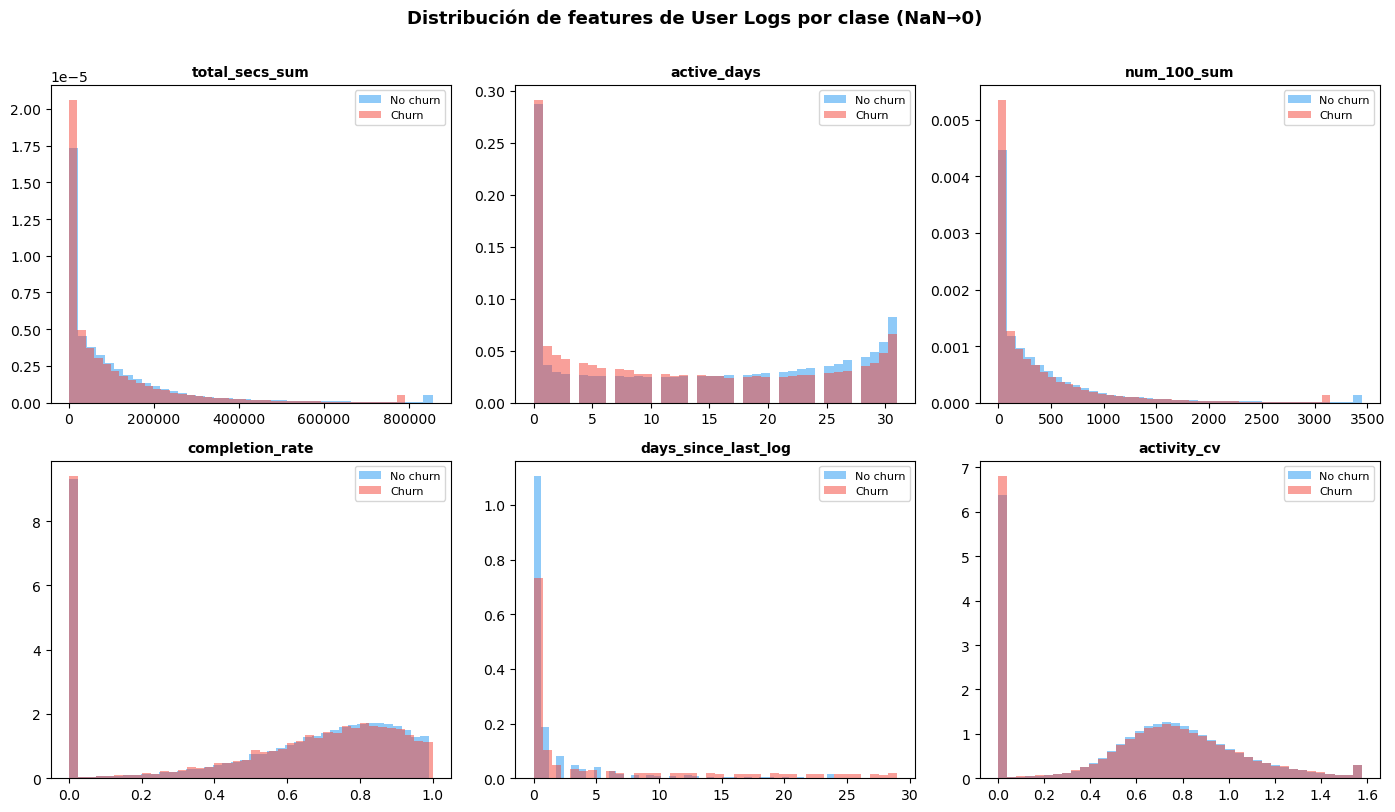

In [27]:
plot_features = ['total_secs_sum', 'active_days', 'num_100_sum', 'completion_rate', 'days_since_last_log', 'activity_cv']
plot_df = df_model_logs[['is_churn'] + plot_features]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(plot_features):
    for churn_val, label, color in [(0, 'No churn', '#2196F3'), (1, 'Churn', '#F44336')]:
        subset = plot_df[plot_df['is_churn'] == churn_val][col]
        cap = subset.quantile(0.99)
        subset = subset.clip(upper=cap)
        axes[i].hist(subset, bins=40, alpha=0.5, label=label, color=color, density=True)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de features de User Logs por clase (NaN→0)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Correlación de features de logs con is_churn

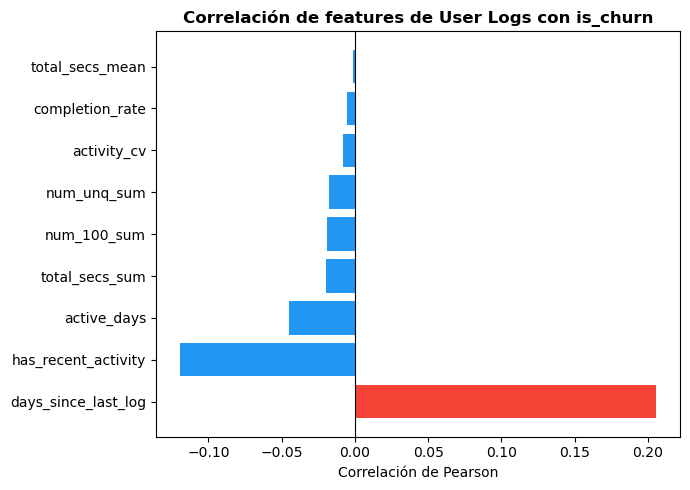

days_since_last_log    0.2056
has_recent_activity   -0.1196
active_days           -0.0447
total_secs_sum        -0.0196
num_100_sum           -0.0188
num_unq_sum           -0.0176
activity_cv           -0.0078
completion_rate       -0.0052
total_secs_mean       -0.0014


In [28]:
correlations = df_model_logs[['is_churn'] + check_cols].corr()['is_churn'].drop('is_churn').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#F44336' if v > 0 else '#2196F3' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de features de User Logs con is_churn', fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print(correlations.round(4).to_string())

## Paso 4 — Guardar features de logs

Guardamos las features listas para mergear con el modelo en la próxima iteración.

El archivo incluye **todos los usuarios** del dataset base: los activos con sus métricas reales, y los inactivos con ceros (su ausencia ya es la señal).

In [29]:
save_cols = ['msno'] + log_feature_cols

df_model_logs[save_cols].to_csv('../data/processed/log_features_march2017.csv', index=False)

print(f"Guardado: data/processed/log_features_march2017.csv")
print(f"Shape   : {df_model_logs[save_cols].shape}")
print(f"\nFeatures incluidas ({len(log_feature_cols)}):")
for col in log_feature_cols:
    print(f"  - {col}")

Guardado: data/processed/log_features_march2017.csv
Shape   : (970960, 12)

Features incluidas (11):
  - total_secs_sum
  - total_secs_mean
  - num_unq_sum
  - num_unq_mean
  - num_100_sum
  - active_days
  - days_since_last_log
  - has_recent_activity
  - completion_rate
  - peak_day_secs
  - activity_cv


## Conclusiones

Completar después de correr el notebook.

**Preguntas clave a responder con los resultados:**
- ¿Qué porcentaje de usuarios del dataset NO tiene actividad en marzo? (usuarios inactivos)
- ¿La diferencia de churn rate entre usuarios CON y SIN logs es grande? (validación de la señal principal)
- ¿Qué feature de logs tiene mayor correlación con `is_churn`?
- ¿`active_days` o `total_secs_sum` discriminan mejor?
- ¿`completion_rate` (calidad de escucha) tiene señal propia más allá del volumen?

---

## Próximo paso — Iteración v3

Con `data/processed/log_features_march2017.csv` generado, la siguiente iteración es directa:

1. Cargar `df_model_baseline_v1.csv`
2. Mergear con `log_features_march2017.csv` en `msno`
3. Entrenar Random Forest con el set de features completo (transactions + members + logs)
4. Comparar ROC AUC con iteración v2 (0.673)

**Expectativa:** salto a 0.72–0.80. Las features de uso real del producto son más predictivas que las de pago.